<a href="https://colab.research.google.com/github/Arnab-apk/100_Days_Of_ML/blob/arnab/End_to_end_toy_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Primary steps in ML Life cycle**

#1 Preprocessing + EDA +Feature Selection
#2 Extracting input and output cells
#3 Scaling of values
#4 Train test split
#5 Training the model
#6 Evaluation nof the model
#7 Deployment of the model

# Importing required libraries

In [ ]:
import numpy as np
import pandas as pd

#Using the read.csv function from pandas to construct a dataframe

In [ ]:
df=pd.read_csv('/content/placement.csv')

#Printing the dataframe

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


#df.info gives the d type for each columns in the dataframe

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


#A small data preprocessing step

In [ ]:
df=df.iloc[:,1:]
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


#Importing a data visualisation library pyplot

In [ ]:
import matplotlib.pyplot as plt

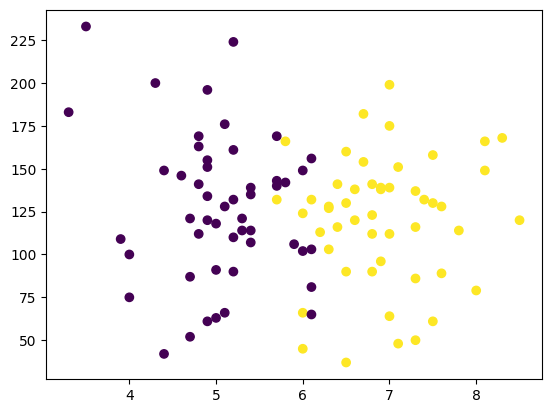

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

#Extracting input and output cells

In [ ]:
X=df.iloc[:,0:2]
Y=df.iloc[:,-1]

#Input

In [ ]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


#Output

In [ ]:
Y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


#Train Test split

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1)

In [ ]:
X_train

,cgpa,iq
75,4.8,169.0
39,4.6,146.0
59,4.8,112.0
65,8.1,166.0
7,5.0,63.0
...,...,...
96,4.4,42.0
73,4.9,61.0
43,6.8,141.0
9,5.1,66.0


In [ ]:
X_test

,cgpa,iq
15,5.1,176.0
30,7.6,128.0
45,6.0,66.0
95,4.3,200.0
8,6.1,156.0
72,7.3,116.0
22,4.9,120.0
54,6.4,141.0
3,7.4,132.0
81,5.4,107.0


In [ ]:
Y_train

,placement
70,1
58,1
4,0
71,1
42,1
...,...
33,0
54,1
49,0
93,1


In [ ]:
Y_test

,placement
15,0
30,1
45,1
95,0
8,0
72,1
22,0
54,1
3,1
81,0


#Scaling of Data

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [ ]:
#model training
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,Y_train)

LogisticRegression()

In [ ]:
#model eval
y_pred=model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

0.8

<Axes: >

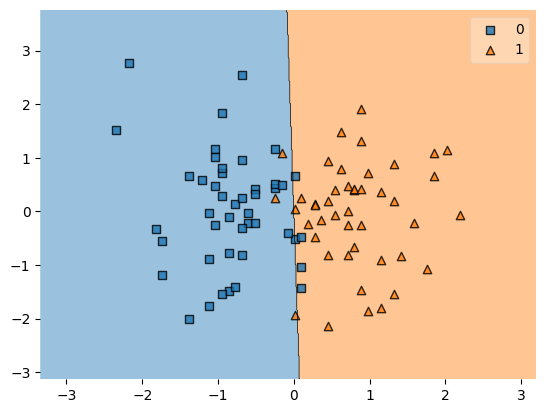

In [ ]:
#trend followed by the model
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train,y=Y_train.values,clf=model)


In [ ]:
import pickle
pickle.dump(model,open('model.pkl','wb'))